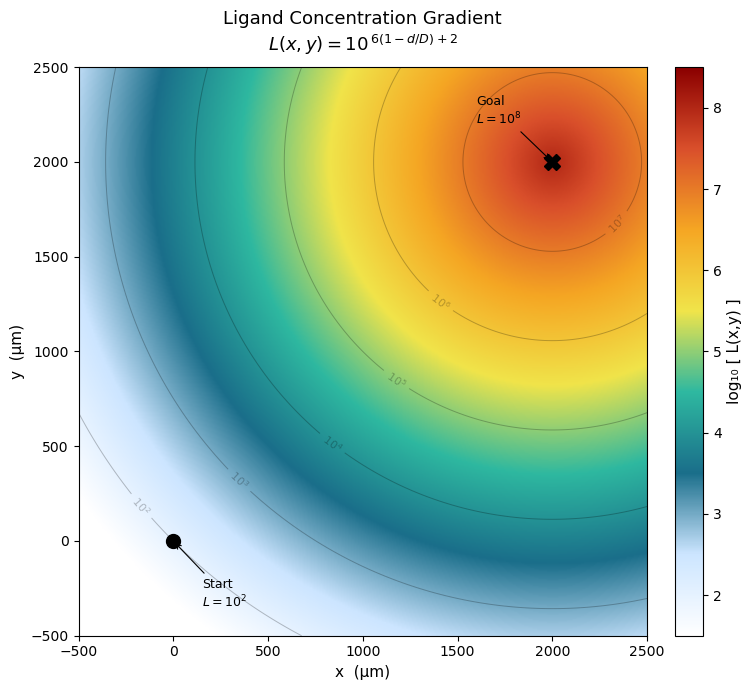

Plot saved.


In [8]:

"""
Ligand Concentration Gradient — 2D Heatmap
L(x, y) = 10^( 6*(1 - d/D) + 2 )
where d = distance from (x,y) to goal, D = distance from origin to goal
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import math

# --- Parameters ---
start = [0.0, 0.0]
goal  = [2000.0, 2000.0]
start_exponent = 2
goal_exponent  = 8

# --- Helper functions ---
def distance(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def calculate_concentration(x, y, origin_to_center):
    """Returns log10 of concentration at point (x, y)."""
    d = distance([x, y], goal)
    exponent = (1 - d / origin_to_center) * (goal_exponent - start_exponent) + start_exponent
    return exponent  # log10(L), so L = 10^exponent

# --- Build concentration grid ---
origin_to_center = distance(start, goal)

grid_min, grid_max = -500, 2500
resolution = 400

x_vals = np.linspace(grid_min, grid_max, resolution)
y_vals = np.linspace(grid_min, grid_max, resolution)
X, Y = np.meshgrid(x_vals, y_vals)

Z = np.zeros_like(X)
for i in range(resolution):
    for j in range(resolution):
        Z[i, j] = calculate_concentration(X[i, j], Y[i, j], origin_to_center)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Custom colormap: white (low) → light blue → teal → yellow → red (high)
colors_list = [
    '#ffffff',   # white           — lowest concentration
    '#cce5ff',   # very light blue
    '#1a6e8a',   # teal-blue
    '#2eb8a0',   # teal-green
    '#f0e44a',   # yellow
    '#f5a623',   # orange
    '#d94f2b',   # red-orange
    '#8b0000',   # deep red        — highest concentration
]
cmap = LinearSegmentedColormap.from_list('concentration', colors_list, N=512)

img = ax.imshow(
    Z,
    extent=[grid_min, grid_max, grid_min, grid_max],
    origin='lower',
    cmap=cmap,
    vmin=start_exponent - 0.5,
    vmax=goal_exponent + 0.5,
    interpolation='bilinear',
    aspect='equal'
)

# Colorbar
cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('log₁₀ [ L(x,y) ]', color='black', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
cbar.outline.set_edgecolor('black')

# Contour lines at each order of magnitude
contour_levels = np.arange(start_exponent, goal_exponent + 1, 1)
cs = ax.contour(X, Y, Z, levels=contour_levels, colors='black', alpha=0.25, linewidths=0.7)
ax.clabel(cs, fmt=lambda v: f'$10^{{{int(v)}}}$', fontsize=8, colors='black')

# Mark start and goal
ax.plot(*start, 'o', color='black', markersize=10, zorder=5)
ax.plot(*goal,  'X', color='black', markersize=12, zorder=5)
ax.annotate('Start\n$L=10^2$', xy=start, xytext=(150, -350),
            color='black', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8))
ax.annotate('Goal\n$L=10^8$', xy=goal, xytext=(1600, 2200),
            color='black', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

ax.set_xlim(grid_min, grid_max)
ax.set_ylim(grid_min, grid_max)
ax.set_xlabel('x  (µm)', color='black', fontsize=11)
ax.set_ylabel('y  (µm)', color='black', fontsize=11)
ax.set_title('Ligand Concentration Gradient\n$L(x,y) = 10^{\\,6(1-d/D)+2}$',
             color='black', fontsize=13, pad=12)
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
plt.savefig('concentration_gradient_2D.png',
            dpi=350, bbox_inches='tight', facecolor='white')
plt.show()
print("Plot saved.")